# Human-LLM Alignment Analysis & Signature Optimization

This notebook computes human-LLM alignment metrics, inter-annotator agreement,
and optimizes DSPy judge signatures to maximize alignment.

**Sections covers:**
- Section 1: Setup & Data Loading
- Section 2. Self Consistency for Human Annotators
- Section 3. Inter-Model Reliability
- Section 4: Human-LLM Alignment
- Section 5: Signature Optimization
- Section 6: Filter out the Annotated Questions for Next Step
---

## 1. Setup & Data Loading

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the evaluation package is importable
sys.path.insert(0, str(Path(".").resolve().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd

from langdmta_eval.alignment import (
    ANNOTATION_METRICS,
    alignment_summary_table,
    compute_all_alignments,
    compute_all_alignments_by_model,
    compute_all_inter_annotator,
    compute_all_llm_inter_judge_agreement,
    compute_all_self_consistency,
    drop_duplicates,
    get_majority_llm_vote_df,
    get_majority_vote_df,
    get_majority_human_scores,
    inter_annotator_summary_table,
    llm_inter_judge_summary_table,
    load_llm_runs,
    load_multiple_annotators,
    load_multiple_models,
    multi_model_summary_table,
    plot_alignment_bar_chart,
    plot_all_confusion_matrices,
    plot_inter_annotator_barplot,
    plot_llm_inter_judge_barplot,
    plot_multi_alignment_comparison,
    plot_self_consistency_barplot,
    self_consistency_summary_table,
)

print(f"Annotation metrics: {ANNOTATION_METRICS}")

Annotation metrics: ['relevancy', 'completeness', 'structural_clarity', 'scope_adherence']


In [2]:
import os
os.getcwd()

'/home/kpzn768/Repos/langdmta-lab/evaluation/langdmta_eval/human_annotation'

In [3]:
# =============================================================
# CONFIGURATION - Edit these paths to match your annotation data
# =============================================================

BASE_DIR_MODELS = Path("../../../Emmas_results/judge_results")
BASE_DIR_ANNOTATION = Path("../../../Emmas_results/human_annotation").resolve() #Path(".").resolve()

# --- All models to load and compare ---
MODEL_LLM_SCORES = {
    "GPT-5": [str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_azure_gpt-5_run1.json"),
              str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_azure_gpt-5_run2.json"),
              str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_azure_gpt-5_run3.json"),
              ],
    "Gemini 3.1 Pro": [str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_openai_google_gemini-3.1-pro-preview_run1.json"),
                       str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_openai_google_gemini-3.1-pro-preview_run2.json"),
                       str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_openai_google_gemini-3.1-pro-preview_run3.json"),
                       ],
    "Claude Opus 4.7": [str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_bedrock_us.anthropic.claude-opus-4-7_run1.json"),
                        str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_bedrock_us.anthropic.claude-opus-4-7_run2.json"),
                        str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_bedrock_us.anthropic.claude-opus-4-7_run3.json"),
                        ],
    "Llama 3.1 70B": [str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_bedrock_us_meta_llama3-1-70b-instruct_run1.json"),
                      str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_bedrock_us_meta_llama3-1-70b-instruct_run2.json"),
                      str(BASE_DIR_MODELS / "test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_bedrock_us_meta_llama3-1-70b-instruct_run3.json")
                      ],
}

# --- Models to generate confusion matrices for (subset of MODEL_LLM_SCORES keys) ---
CONFUSION_MATRIX_MODELS = ["GPT-5", "Claude Opus 4.7", "Gemini 3.1 Pro", "llama-3.1-pro"]

# --- Models to run optimization for (subset of MODEL_LLM_SCORES keys) ---
OPTIMIZATION_MODELS = ["GPT-5", "Claude Opus 4.7", "Gemini 3.1 Pro"]

# Multiple annotator files (shared across all models)
ANNOTATOR_CSVS = {
    "SG": str(BASE_DIR_ANNOTATION / "round2/annotator_sheet_annotated_SG.csv"),
    "TS": str(BASE_DIR_ANNOTATION / "round2/annotator_sheet_annotated_TS.csv"),
    "LS": str(BASE_DIR_ANNOTATION / "round2/annotator_sheet_annotated_LS.csv"),
    "ND": str(BASE_DIR_ANNOTATION / "round2/annotator_sheet_annotated_ND.csv"),
    "RMO": str(BASE_DIR_ANNOTATION / "round2/annotator_sheet_annotated_RMO.csv"),
}

IS_MULTI_MODEL = len(MODEL_LLM_SCORES) > 1

# Output directories
FIGURES_DIR = BASE_DIR_MODELS / "figures-2"
FIGURES_DIR.mkdir(exist_ok=True)

In [4]:
# Load all annotator data (for all models)
if IS_MULTI_MODEL:
    df = load_multiple_models(ANNOTATOR_CSVS, MODEL_LLM_SCORES)
else:
    first_model = next(iter(MODEL_LLM_SCORES))
    df = load_multiple_annotators(ANNOTATOR_CSVS, MODEL_LLM_SCORES[first_model])
    df["model_id"] = first_model

print(f"Total records: {len(df)}")
print(f"Models: {df['model_id'].unique().tolist()}")
print(f"Metrics: {df['metric'].unique().tolist()}")
print()
print("Records per annotator:")
print(df.groupby('annotator_id')['annotation_id'].nunique())
if IS_MULTI_MODEL:
    print("\nRecords per model:")
    print(df.groupby('model_id')['annotation_id'].nunique())

Loaded 35 annotations from: annotator_sheet_annotated_SG.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_TS.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_LS.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_ND.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_RMO.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_SG.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_TS.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_LS.csv
Matched 35 of 35 annotated cases from 111 JSON entries
Loaded 35 annotations from: annotator_sheet_annotated_ND.csv
Matched 35

---
## 2. Self Consistency for Human Annotators
Evaluating each annotator and the mean sel-alignment for a set of duplicated questions.

In [5]:

# Self-consistency uses only human scores — filter to one model to avoid
# duplicated rows when multiple models are loaded
_first_model = next(iter(MODEL_LLM_SCORES))
sc_df = df[df["model_id"] == _first_model]

# Before dropping duplicates
sc_results = compute_all_self_consistency(sc_df)
sc_table = self_consistency_summary_table(sc_results)
display(sc_table.round(3))

# Then drop duplicates for further analyses
df = drop_duplicates(df)

,metric,annotator,n_pairs,exact_match,mean_abs_diff,kappa_weighted
0,relevancy,LS,5,0.80,0.100,0.000
1,relevancy,ND,5,0.80,0.100,0.545
2,relevancy,RMO,5,0.60,0.200,-0.250
3,relevancy,SG,5,0.80,0.100,0.545
4,relevancy,TS,5,0.80,0.100,0.706
5,completeness,LS,5,0.60,0.200,0.375
6,completeness,ND,5,1.00,0.000,1.000
7,completeness,RMO,5,1.00,0.000,1.000
8,completeness,SG,5,0.80,0.100,0.000
9,completeness,TS,5,0.80,0.100,0.545


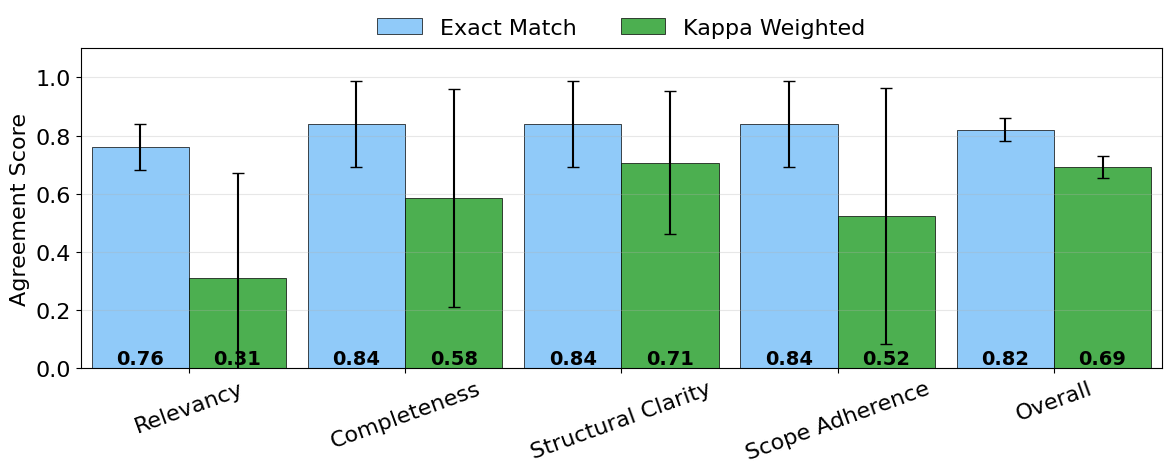

In [17]:
# 
plot_self_consistency_barplot(sc_table, metric=["exact_match", "kappa_weighted"], figsize=(12,5), 
                              save_path=FIGURES_DIR / "self_consistency.pdf"
                              )
plt.show()

In [7]:
# Inter-annotator agreement (human-only — use single model slice to avoid duplication)
iaa_df = df[df["model_id"] == _first_model]
iaa_results = compute_all_inter_annotator(iaa_df)
iaa_table = inter_annotator_summary_table(iaa_results)

print("Inter-Annotator Agreement (Fleiss' kappa & mean pairwise weighted Cohen's kappa):")
display(iaa_table.round(3))


Inter-Annotator Agreement (Fleiss' kappa & mean pairwise weighted Cohen's kappa):


,metric,n,n_annotators,fleiss_kappa,mean_pairwise_kappa,LS_vs_ND,LS_vs_RMO,LS_vs_SG,LS_vs_TS,ND_vs_RMO,ND_vs_SG,ND_vs_TS,RMO_vs_SG,RMO_vs_TS,SG_vs_TS
0,relevancy,30,5,0.267,0.297,0.259,0.429,0.016,0.103,0.143,0.180,0.615,0.231,0.667,0.328
1,completeness,30,5,0.631,0.693,0.489,0.637,0.794,0.688,0.597,0.655,0.717,0.845,0.729,0.779
2,structural_clarity,30,5,0.262,0.257,0.340,0.135,0.250,0.087,0.528,0.562,0.273,0.250,0.087,0.062
3,scope_adherence,30,5,0.119,0.154,-0.047,-0.067,0.492,0.239,0.132,-0.034,0.211,-0.057,0.554,0.123
4,overall,120,5,0.542,0.588,0.591,0.538,0.584,0.593,0.579,0.610,0.653,0.495,0.718,0.518


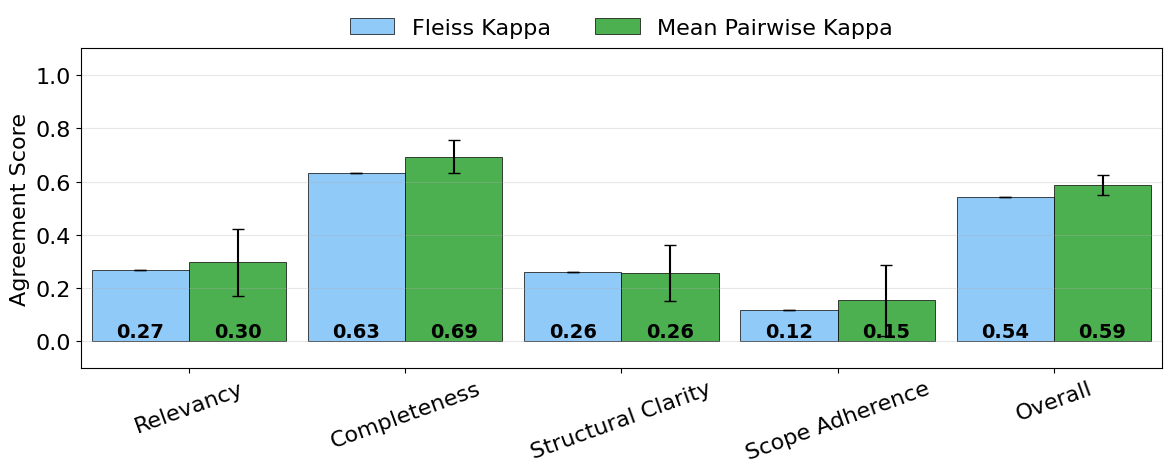

In [19]:

fig = plot_inter_annotator_barplot(iaa_results, figsize=(12,5), 
                                   save_path=FIGURES_DIR / "inter_annotator_agreement.pdf"
                                   )

In [8]:
# Show pairwise kappas for detailed view
for metric, result in iaa_results.items():
    if result.pairwise_kappas:
        print(f"\n{metric}:")
        for pair, k in result.pairwise_kappas.items():
            print(f"  {pair}: {k:.3f}" if not pd.isna(k) else f"  {pair}: N/A")


relevancy:
  LS_vs_ND: 0.259
  LS_vs_RMO: 0.429
  LS_vs_SG: 0.016
  LS_vs_TS: 0.103
  ND_vs_RMO: 0.143
  ND_vs_SG: 0.180
  ND_vs_TS: 0.615
  RMO_vs_SG: 0.231
  RMO_vs_TS: 0.667
  SG_vs_TS: 0.328

completeness:
  LS_vs_ND: 0.489
  LS_vs_RMO: 0.637
  LS_vs_SG: 0.794
  LS_vs_TS: 0.688
  ND_vs_RMO: 0.597
  ND_vs_SG: 0.655
  ND_vs_TS: 0.717
  RMO_vs_SG: 0.845
  RMO_vs_TS: 0.729
  SG_vs_TS: 0.779

structural_clarity:
  LS_vs_ND: 0.340
  LS_vs_RMO: 0.135
  LS_vs_SG: 0.250
  LS_vs_TS: 0.087
  ND_vs_RMO: 0.528
  ND_vs_SG: 0.562
  ND_vs_TS: 0.273
  RMO_vs_SG: 0.250
  RMO_vs_TS: 0.087
  SG_vs_TS: 0.062

scope_adherence:
  LS_vs_ND: -0.047
  LS_vs_RMO: -0.067
  LS_vs_SG: 0.492
  LS_vs_TS: 0.239
  ND_vs_RMO: 0.132
  ND_vs_SG: -0.034
  ND_vs_TS: 0.211
  RMO_vs_SG: -0.057
  RMO_vs_TS: 0.554
  SG_vs_TS: 0.123

overall:
  LS_vs_ND: 0.591
  LS_vs_RMO: 0.538
  LS_vs_SG: 0.584
  LS_vs_TS: 0.593
  ND_vs_RMO: 0.579
  ND_vs_SG: 0.610
  ND_vs_TS: 0.653
  RMO_vs_SG: 0.495
  RMO_vs_TS: 0.718
  SG_vs_TS: 0.518


---
## 3 LLM Intra-Judge Agreement

Measure how consistently each LLM judge scores across its 3 independent runs,
using the same Fleiss' κ and pairwise Cohen's κ used for human annotators.


In [9]:
# Load all 3 runs per model (separate from the main df used for alignment)
llm_runs_df = load_llm_runs(ANNOTATOR_CSVS, MODEL_LLM_SCORES)

llm_runs_df = drop_duplicates(llm_runs_df)

print(f"LLM runs loaded: {len(llm_runs_df)} rows")
print(f"Models: {llm_runs_df['model_id'].unique().tolist()}")
print(f"Runs per model: {llm_runs_df.groupby('model_id')['run_id'].unique().apply(list).to_dict()}")


LLM runs loaded: 1440 rows
Models: ['GPT-5', 'Gemini 3.1 Pro', 'Claude Opus 4.7', 'Llama 3.1 70B']
Runs per model: {'Claude Opus 4.7': ['run1', 'run2', 'run3'], 'GPT-5': ['run1', 'run2', 'run3'], 'Gemini 3.1 Pro': ['run1', 'run2', 'run3'], 'Llama 3.1 70B': ['run1', 'run2', 'run3']}


In [10]:
# Compute inter-judge agreement across runs for each model
llm_iaa_results = compute_all_llm_inter_judge_agreement(llm_runs_df)
llm_iaa_table = llm_inter_judge_summary_table(llm_iaa_results)

print("LLM Inter-Judge Agreement (Fleiss' kappa & mean pairwise weighted Cohen's kappa across 3 runs):")
display(llm_iaa_table.round(3))


LLM Inter-Judge Agreement (Fleiss' kappa & mean pairwise weighted Cohen's kappa across 3 runs):


,model,metric,n,n_annotators,fleiss_kappa,mean_pairwise_kappa,run1_vs_run2,run1_vs_run3,run2_vs_run3
0,Claude Opus 4.7,relevancy,28,3,0.920,0.928,0.891,0.891,1.000
1,Claude Opus 4.7,completeness,28,3,0.889,0.913,0.957,0.914,0.870
2,Claude Opus 4.7,structural_clarity,28,3,0.869,0.874,1.000,0.811,0.811
3,Claude Opus 4.7,scope_adherence,28,3,0.864,0.869,0.804,0.907,0.895
4,Claude Opus 4.7,overall,112,3,0.918,0.930,0.948,0.923,0.920
5,GPT-5,relevancy,30,3,0.869,0.890,0.887,0.891,0.894
6,GPT-5,completeness,30,3,0.899,0.921,0.961,0.883,0.921
7,GPT-5,structural_clarity,30,3,0.845,0.855,0.783,1.000,0.783
8,GPT-5,scope_adherence,30,3,0.330,0.374,0.334,0.514,0.273
9,GPT-5,overall,120,3,0.757,0.772,0.765,0.811,0.739


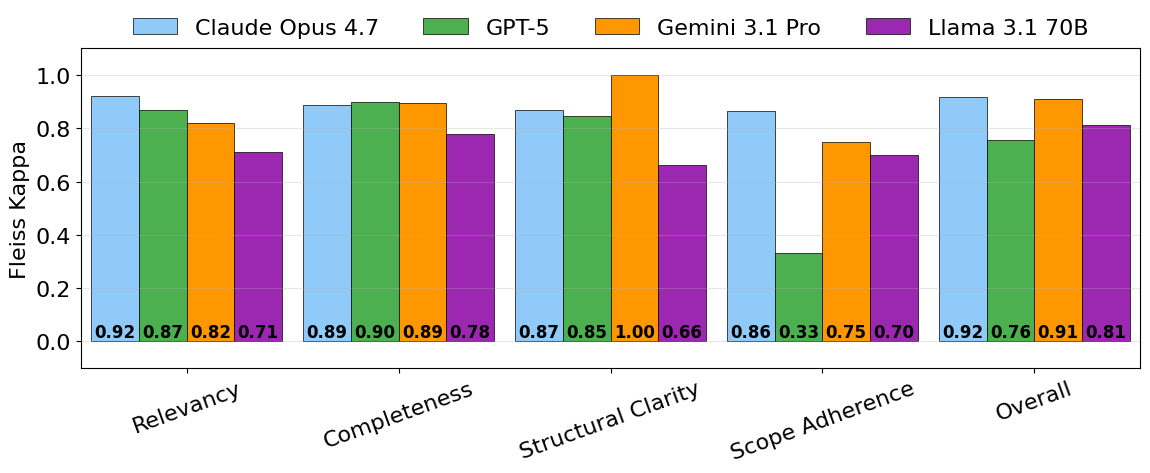

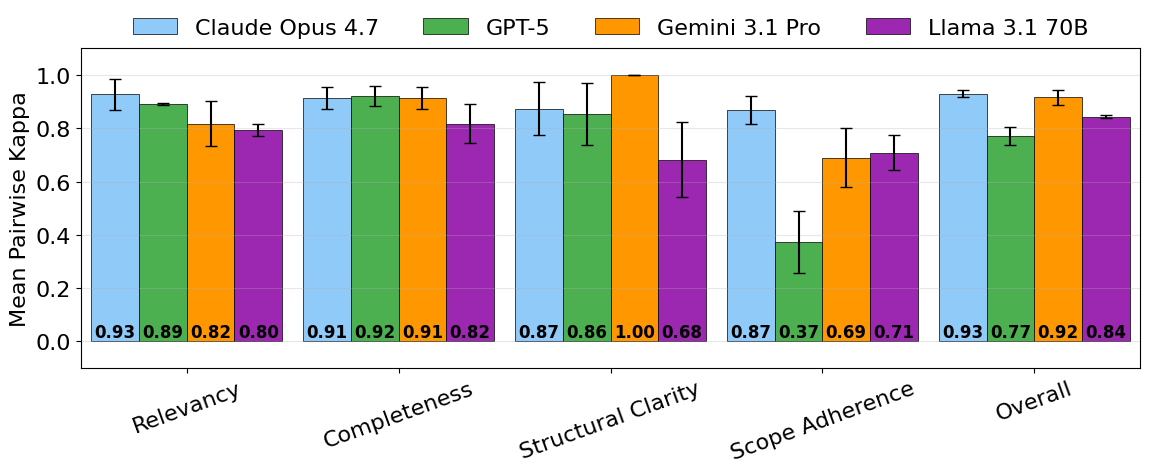

In [24]:
fig = plot_llm_inter_judge_barplot(
    llm_iaa_results,
    agreement_metric="fleiss_kappa",
    figsize=(12, 5),
    error_bars=False,
    save_path=FIGURES_DIR / "llm_inter_judge_fleiss_kappa.pdf",
)
plt.show()

fig = plot_llm_inter_judge_barplot(
    llm_iaa_results,
    agreement_metric="mean_pairwise_kappa",
    figsize=(12, 5),
    save_path=FIGURES_DIR / "llm_inter_judge_mean_pairwise_kappa.pdf",
)
plt.show()


---
## 4. Human-LLM Alignment

Compute Human-LLM agreement per-annotator and using majority vote.

### Per-annotator

In [11]:
# Per-annotator alignment (per model)
for model_id in MODEL_LLM_SCORES:
    model_df = df[df["model_id"] == model_id]
    for ann_id in ANNOTATOR_CSVS:
        results = compute_all_alignments(model_df, annotator_id=ann_id)
        table = alignment_summary_table(results)
        print(f"\n=== Annotator: {ann_id} | Model: {model_id} ===")
        display(table.round(3))


=== Annotator: SG | Model: GPT-5 ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.833,0.643,0.701,0.791,0.000
1,completeness,30,0.467,0.212,0.412,0.823,0.000
2,structural_clarity,30,0.567,0.137,0.125,0.246,0.191
3,scope_adherence,30,0.233,0.032,0.047,0.196,0.298
4,overall,120,0.525,0.237,0.355,0.503,0.000



=== Annotator: TS | Model: GPT-5 ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.800,0.516,0.571,0.744,0.000
1,completeness,30,0.633,0.457,0.599,0.831,0.000
2,structural_clarity,30,0.900,0.526,0.526,0.598,0.000
3,scope_adherence,30,0.400,0.165,0.184,0.287,0.125
4,overall,120,0.683,0.460,0.558,0.634,0.000



=== Annotator: LS | Model: GPT-5 ===


...

,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.833,0.315,0.300,0.436,0.016
1,completeness,30,0.733,0.553,0.543,0.579,0.001
2,structural_clarity,30,0.867,0.423,0.423,0.423,0.020
3,scope_adherence,30,0.767,0.146,0.186,0.314,0.091
4,overall,120,0.800,0.630,0.627,0.697,0.000



=== Annotator: ND | Model: Llama 3.1 70B ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.767,0.041,0.100,0.168,0.374
1,completeness,30,0.700,0.521,0.568,0.630,0.000
2,structural_clarity,30,0.700,0.151,0.151,0.171,0.366
3,scope_adherence,30,0.867,0.500,0.390,0.222,0.238
4,overall,120,0.758,0.574,0.583,0.620,0.000



=== Annotator: RMO | Model: Llama 3.1 70B ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.833,0.434,0.559,0.781,0.000
1,completeness,30,0.800,0.659,0.660,0.681,0.000
2,structural_clarity,30,0.733,-0.154,-0.154,-0.154,0.417
3,scope_adherence,30,0.633,0.286,0.304,0.400,0.029
4,overall,120,0.750,0.563,0.632,0.736,0.000


### Majority Vote

In [12]:
# Replace llm_score in df with the majority vote across the 3 LLM runs
# llm_score is now based on majority vote
df = get_majority_llm_vote_df(df, llm_runs_df)

# Majority-vote alignment per model
all_model_results = compute_all_alignments_by_model(df, use_majority_vote=True)

for model_id, results in all_model_results.items():
    table = alignment_summary_table(results)
    print(f"\n=== Human-LLM Alignment (Majority Vote) - {model_id} ===")
    display(table.round(3))

# Keep a reference for backward compatibility
baseline_results = all_model_results[next(iter(MODEL_LLM_SCORES))]


=== Human-LLM Alignment (Majority Vote) - Claude Opus 4.7 ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,28,0.929,0.711,0.711,0.743,0.000
1,completeness,28,0.714,0.535,0.639,0.809,0.000
2,structural_clarity,28,0.714,0.152,0.152,0.152,0.442
3,scope_adherence,28,0.893,0.644,0.533,0.372,0.052
4,overall,112,0.812,0.664,0.696,0.743,0.000



=== Human-LLM Alignment (Majority Vote) - GPT-5 ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.700,0.270,0.360,0.601,0.000
1,completeness,30,0.533,0.300,0.462,0.793,0.000
2,structural_clarity,30,0.833,0.380,0.380,0.484,0.007
3,scope_adherence,30,0.267,0.093,0.136,0.331,0.074
4,overall,120,0.583,0.306,0.452,0.631,0.000



=== Human-LLM Alignment (Majority Vote) - Gemini 3.1 Pro ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.900,0.609,0.609,0.614,0.000
1,completeness,30,0.767,0.619,0.688,0.800,0.000
2,structural_clarity,30,0.833,0.380,0.380,0.484,0.007
3,scope_adherence,30,0.900,0.676,0.681,0.739,0.000
4,overall,120,0.850,0.728,0.764,0.796,0.000



=== Human-LLM Alignment (Majority Vote) - Llama 3.1 70B ===


,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,relevancy,30,0.767,0.205,0.386,0.609,0.000
1,completeness,30,0.867,0.771,0.764,0.747,0.000
2,structural_clarity,30,0.767,0.234,0.234,0.247,0.188
3,scope_adherence,30,0.900,0.672,0.672,0.711,0.000
4,overall,120,0.825,0.688,0.721,0.769,0.000


### Cross-Model Alignment Comparison

Compare alignment metrics across all loaded LLM judge models.


=== Cross-Model Alignment Comparison (Majority Vote) ===


,model,metric,n,exact_match,kappa_unweighted,kappa_weighted,spearman_rho,spearman_p
0,Claude Opus 4.7,relevancy,28,0.929,0.711,0.711,0.743,0.000
1,Claude Opus 4.7,completeness,28,0.714,0.535,0.639,0.809,0.000
2,Claude Opus 4.7,structural_clarity,28,0.714,0.152,0.152,0.152,0.442
3,Claude Opus 4.7,scope_adherence,28,0.893,0.644,0.533,0.372,0.052
4,Claude Opus 4.7,overall,112,0.812,0.664,0.696,0.743,0.000
5,GPT-5,relevancy,30,0.700,0.270,0.360,0.601,0.000
6,GPT-5,completeness,30,0.533,0.300,0.462,0.793,0.000
7,GPT-5,structural_clarity,30,0.833,0.380,0.380,0.484,0.007
8,GPT-5,scope_adherence,30,0.267,0.093,0.136,0.331,0.074
9,GPT-5,overall,120,0.583,0.306,0.452,0.631,0.000


Cohen's kappa weighted scores by model:


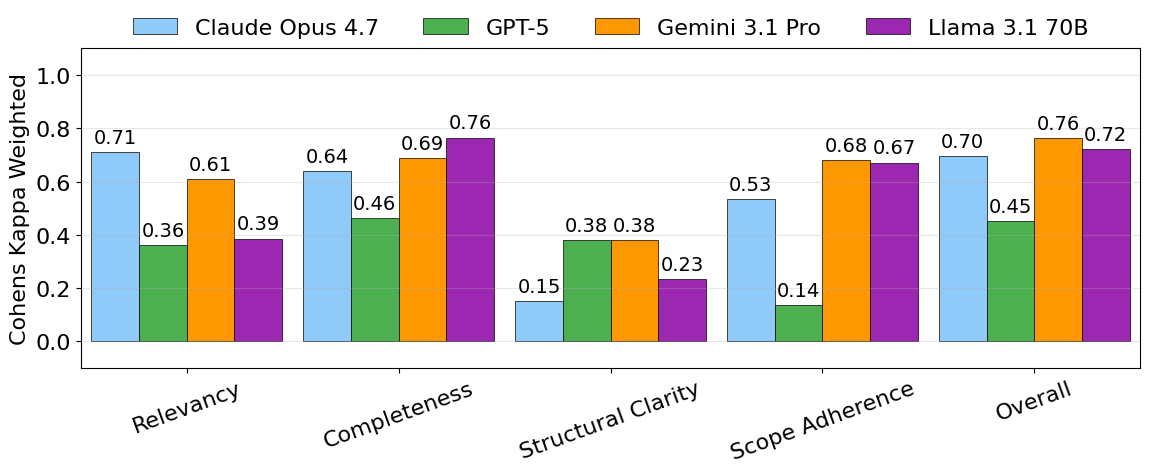

Cohen's kappa unweighted (exact match) scores by model:


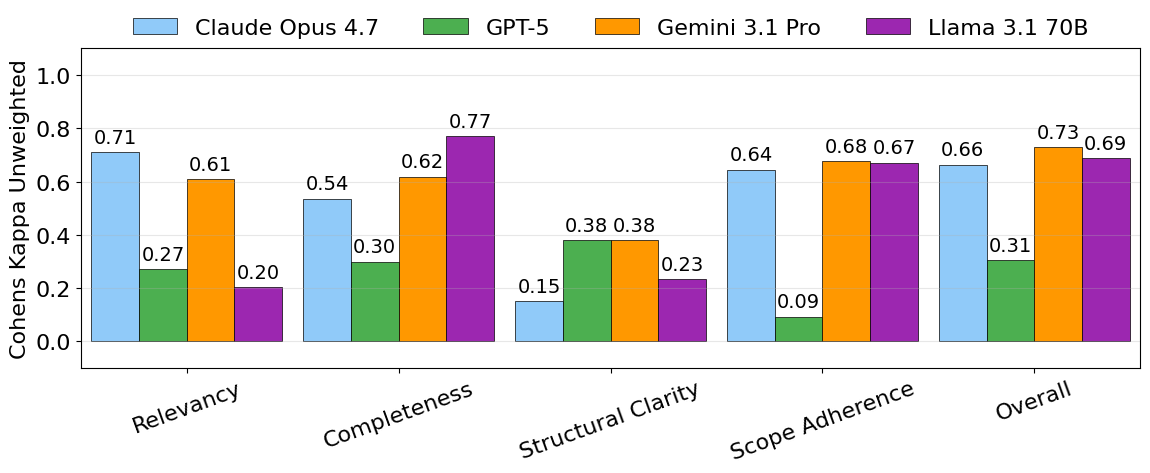

Exact match scores by model:


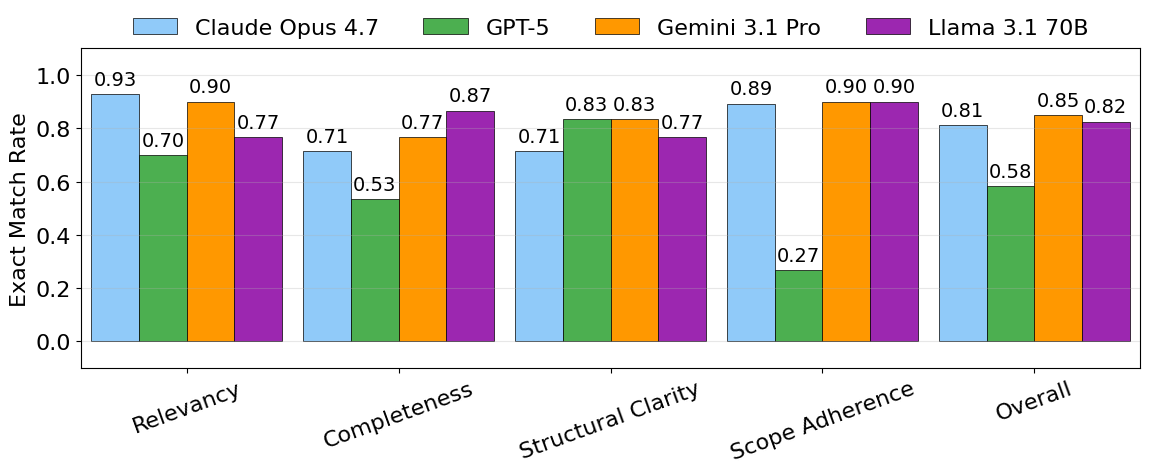

In [13]:
# Cross-model comparison table
if IS_MULTI_MODEL:
    multi_table = multi_model_summary_table(all_model_results)
    print("\n=== Cross-Model Alignment Comparison (Majority Vote) ===")
    display(multi_table.round(3))
else:
    print("Single model configured — skipping cross-model comparison table")
print("Cohen's kappa weighted scores by model:")
# Cross-model bar chart (works with 1+ models)
fig = plot_multi_alignment_comparison(
    all_model_results,
    figsize=(12, 5),
    metric_key="cohens_kappa_weighted",
    save_path=str(FIGURES_DIR / "cross_model_alignment_weighted_kappa.pdf") if IS_MULTI_MODEL else None,
)
plt.show()
print("Cohen's kappa unweighted (exact match) scores by model:")
# Cross-model bar chart (works with 1+ models)
fig = plot_multi_alignment_comparison(
    all_model_results,
    figsize=(12, 5),
    metric_key="cohens_kappa_unweighted",
    save_path=str(FIGURES_DIR / "cross_model_alignment_unweighted_kappa.pdf") if IS_MULTI_MODEL else None,
)
plt.show()
print("Exact match scores by model:")
# Cross-model bar chart (works with 1+ models)
fig = plot_multi_alignment_comparison(
    all_model_results,
    figsize=(12, 5),
    metric_key="exact_match_rate",
    save_path=str(FIGURES_DIR / "cross_model_alignment_exact_match.pdf") if IS_MULTI_MODEL else None,
)
plt.show()

---
### Confusion Matrices

In [ ]:
# Plot confusion matrices for selected models
for model_id in CONFUSION_MATRIX_MODELS:
    model_results = all_model_results[model_id]
    print(f"\n--- {model_id}: Confusion Matrices ---")
    fig = plot_all_confusion_matrices(
        model_results,
        normalize=False,
        #save_path=str(FIGURES_DIR / f"figure4_confusion_matrices_{model_id}.pdf"),
    )
    plt.show()

In [ ]:
# Normalized confusion matrices for selected models
for model_id in CONFUSION_MATRIX_MODELS:
    model_results = all_model_results[model_id]
    print(f"\n--- {model_id}: Normalized Confusion Matrices ---")
    fig = plot_all_confusion_matrices(
        model_results,
        normalize=True,
        #save_path=str(FIGURES_DIR / f"figure4_confusion_matrices_normalized_{model_id}.pdf"),
    )
    plt.show()

In [ ]:
# Alignment bar chart for selected models
for model_id in CONFUSION_MATRIX_MODELS:
    model_results = all_model_results[model_id]
    print(f"\n--- {model_id}: Alignment Bar Chart ---")
    fig = plot_alignment_bar_chart(
        model_results,
        metric_key="cohens_kappa_weighted",
        #save_path=str(FIGURES_DIR / f"baseline_alignment_kappa_{model_id}.pdf"),
    )
    plt.show()

In [14]:
CONFUSION_MATRIX_MODELS

['GPT-5', 'Claude Opus 4.7', 'Gemini 3.1 Pro', 'llama-3.1-pro']

---
### Disagreement Analysis

Identify specific cases where human annotators disagree with the LLM judge.

In [15]:
for model_id in ["Gemini 3.1 Pro"]: #CONFUSION_MATRIX_MODELS:
    model_df = df[df["model_id"] == model_id]
    print(f"\n{'='*50}")
    print(f"Disagreements for model: {model_id}")
    print(f"{'='*50}")
    for metric in ANNOTATION_METRICS:
        ids, human, llm = get_majority_human_scores(model_df, metric)
        if len(ids) == 0:
            continue

        disagreements = ids[human != llm]
        if len(disagreements) > 0:
            print(f"\n  {metric}: {len(disagreements)} disagreement(s) out of {len(ids)} cases")
            for aid in disagreements:
                idx = list(ids).index(aid)
                print(f"    Case {aid}: human={human[idx]}, llm={llm[idx]}")
                print(model_df[model_df["annotation_id"] == aid].iloc[0].question)
                print(model_df[model_df["annotation_id"] == aid].iloc[0].agent_output)


Disagreements for model: Gemini 3.1 Pro

  relevancy: 3 disagreement(s) out of 30 cases
    Case 23: human=0.5, llm=1.0
Hey, I'm looking for some analogs of CC1=C(C(=CC=C1)C)N(CC(=O)NC2=CC=C(C=C2)C3=NOC=N3)C(=O)C4CCS(=O)(=O)CC4. Can you pull up a few and then show me how to make the top 5?
Analyzer:
The provided dataset is empty and does not contain any suitable rows or necessary scoring properties for analysis. No further processing or filtering was performed.
    Case 26: human=1.0, llm=0.5
Hey, can you look for some molecules similar to C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O that have more aromatic rings? And for the most similar one, can you map out its synthesis and list a few related reactions?
Synthesis:
Here’s the detailed breakdown of the work:

---

### 1. Most Similar Molecule Analysis
The reference molecule, "C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)" with 2 aromatic rings, was analyzed. Among the chosen molecules, synthesis and related reactions were explored f

In [31]:
df

,annotation_id,metric,human_label,human_score,llm_score,annotator_id,category,test_name,session,question,agent_output,evaluation_context,human_justification,llm_reasoning,duplicate_of,model_id
0,1,relevancy,RELEVANT,1.0,1.0,SG,Workflow,DesignProperty,test-questions-260429_trial_1,Could you please generate a set of close struc...,Analyzer:\nA total of 12 molecules with fewer ...,Question is within the scope of the agentic sy...,NaN,- Relevancy: The output directly addresses gen...,NaN,GPT-5
1,1,completeness,COMPLETE,1.0,1.0,SG,Workflow,DesignProperty,test-questions-260429_trial_1,Could you please generate a set of close struc...,Analyzer:\nA total of 12 molecules with fewer ...,Question is within the scope of the agentic sy...,NaN,- Relevancy: The output directly addresses gen...,NaN,GPT-5
2,1,structural_clarity,PARTIALLY CLEAR,0.5,1.0,SG,Workflow,DesignProperty,test-questions-260429_trial_1,Could you please generate a set of close struc...,Analyzer:\nA total of 12 molecules with fewer ...,Question is within the scope of the agentic sy...,NaN,- Relevancy: The output directly addresses gen...,NaN,GPT-5
3,1,scope_adherence,ON TARGET,0.5,0.5,SG,Workflow,DesignProperty,test-questions-260429_trial_1,Could you please generate a set of close struc...,Analyzer:\nA total of 12 molecules with fewer ...,Question is within the scope of the agentic sy...,NaN,- Relevancy: The output directly addresses gen...,NaN,GPT-5
4,2,relevancy,PARTIALLY RELEVANT,0.5,0.5,SG,Workflow,DesignPropertySynthesis,test-questions-260429_trial_1,"Hey, can you pull up some analogues of Ciprofl...",Synthesis:\n### Synthesis Route and Similar Re...,Question is within the scope of the agentic sy...,NaN,- Relevance: Mentions an analogue of ciproflox...,NaN,GPT-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,34,scope_adherence,ON TARGET,0.5,0.5,RMO,Workflow,DesignProperty,test-questions-260429_trial_1,can u gen some close analogs of CC(C)CC1=CC=C(...,Analyzer:\nThe filtering process retained 4 mo...,Question is within the scope of the agentic sy...,"no CSV, no similarity",The output is well-structured and easy to pars...,NaN,Llama 3.1 70B
2396,35,relevancy,RELEVANT,1.0,1.0,RMO,Tool,Synonym2SMILES,test-questions-260429_trial_1,"Hey, can you pull the SMARTS pattern for Gleev...",Utility:\nThe SMARTS representation of the mol...,Question is within the scope of the agentic sy...,NaN,The output is well-organized and provides the ...,NaN,Llama 3.1 70B
2397,35,completeness,COMPLETE,1.0,1.0,RMO,Tool,Synonym2SMILES,test-questions-260429_trial_1,"Hey, can you pull the SMARTS pattern for Gleev...",Utility:\nThe SMARTS representation of the mol...,Question is within the scope of the agentic sy...,NaN,The output is well-organized and provides the ...,NaN,Llama 3.1 70B
2398,35,structural_clarity,CLEAR,1.0,1.0,RMO,Tool,Synonym2SMILES,test-questions-260429_trial_1,"Hey, can you pull the SMARTS pattern for Gleev...",Utility:\nThe SMARTS representation of the mol...,Question is within the scope of the agentic sy...,NaN,The output is well-organized and provides the ...,NaN,Llama 3.1 70B


---
## 5. Signature Optimization

Optimize the DSPy judge signatures using human annotations as ground truth.

We compare three approaches:
1. **LabeledFewShot** (k=4): Selects human-annotated examples as few-shot demonstrations
2. **BootstrapFewShot**: Generates Chain-of-Thought demonstrations via a teacher model
3. **MIPROv2**: 

In [16]:
import numpy as np
import dspy

from langdmta_eval import DSPyEvaluator, EvaluatorConfig, TestCase
from langdmta_eval.evaluators.base import build_model_kwargs, create_lm
from langdmta_eval.judges.score_mappings import normalize_score
from langdmta_eval.optimization import (
    OptimizationConfig,
    SignatureOptimizer,
    SignatureVersion,
    build_trainset,
    save_version_history,
    version_comparison_table,
)


In [17]:
OPTIMIZATION_MODELS = ["Gemini 3.1 Pro"] # Change to subset of models to run optimization on

In [ ]:
df#[df["model_id"] == model_id]

In [18]:

# Build training/validation sets per model
model_trainsets = {}
model_valsets = {}

for model_id in OPTIMIZATION_MODELS:
    model_df = df[df["model_id"] == model_id]
    mv_df = get_majority_vote_df(model_df)

    ann_ids = mv_df['annotation_id'].unique()
    train_ids = pd.Series(ann_ids).sample(frac=0.67, random_state=42).values
    train_df = mv_df[mv_df['annotation_id'].isin(train_ids)]
    val_df = mv_df[~mv_df['annotation_id'].isin(train_ids)]

    trainset = build_trainset(train_df, judge_type='comprehensive_v2')
    valset = build_trainset(val_df, judge_type='comprehensive_v2')

    model_trainsets[model_id] = trainset
    model_valsets[model_id] = valset

    print(f"\n--- {model_id} ---")
    print(f"Training set size: {len(trainset)} examples")
    print(f"Validation set size: {len(valset)} examples")
    if len(trainset) > 0:
        print(f"Example fields: {list(trainset[0].keys())}")

model_kwargs = build_model_kwargs("azure")


--- Gemini 3.1 Pro ---
Training set size: 20 examples
Validation set size: 10 examples
Example fields: ['task', 'output', 'evaluation_context', 'tool_calls', 'expected_tool_calls', 'accepted_tool_calls', 'reasoning', 'relevancy', 'completeness', 'structural_clarity', 'scope_adherence']
gateway_url: https://ai-gateway.astrazeneca.net/


In [19]:
USE_SAVED = True

In [20]:

# --- LabeledFewShot Optimization (per model) ---
optimized_lfs_models = {}

for model_id in OPTIMIZATION_MODELS:
    print(f"\n{'='*50}")
    print(f"LabeledFewShot Optimization — {model_id}")
    print(f"{'='*50}")

    trainset = model_trainsets[model_id]
    valset = model_valsets[model_id]

    config_lfs = OptimizationConfig(
        optimizer_type="labeled_fewshot",
        model_name="azure/gpt-5", # model for optimizing judge signature
        model_kwargs=model_kwargs,
        judge_type="capability",
        max_labeled_demos=8,
    )

    optimizer_lfs = SignatureOptimizer(config_lfs, trainset)

    if USE_SAVED:
        # Load previously saved optimized LabeledFewShot module if available
        lfs_path = str(FIGURES_DIR / f"optimized_labeled_fewshot_{model_id.replace(".","").replace(" ", "_")}.json")
        if Path(lfs_path).exists():
            print(f"Loading saved optimized LabeledFewShot module from: {lfs_path}")
            optimized_lfs = optimizer_lfs.load_optimized(lfs_path)
        else:
            raise ValueError(f"No saved optimized LabeledFewShot module found at: {lfs_path}")
    else:
        baseline_score = optimizer_lfs.evaluate(optimizer_lfs.student)
        print(f"Before optimization: {baseline_score:.3f}")

        optimized_lfs = optimizer_lfs.optimize()

        lfs_path = str(FIGURES_DIR / f"optimized_labeled_fewshot_{model_id}.json")
        optimizer_lfs.save_optimized(optimized_lfs, lfs_path)
        print(f"Saved to: {lfs_path}")

        baseline_score = optimizer_lfs.evaluate(optimizer_lfs.student, evalset=valset)
        print(f"Baseline score (no few-shot demos): {baseline_score:.3f}")
        optimized_score = optimizer_lfs.evaluate(optimized_lfs, evalset=valset)
        print(f"Optimized LabeledFewShot score: {optimized_score:.3f}")

    optimized_lfs_models[model_id] = {
        "module": optimized_lfs,
        "optimizer": optimizer_lfs,
        "path": lfs_path,
    }

2026/08/18 12:47:38 WARNING dspy.primitives.base_module: There is a mismatch of dspy version between saved model and current environment. You saved with `dspy==3.1.3`, but now you have `dspy==3.2.1`. This might cause errors or performance downgrade on the loaded model, please consider loading the model in the same environment as the saving environment.



LabeledFewShot Optimization — Gemini 3.1 Pro
Loading saved optimized LabeledFewShot module from: ../../../Emmas_results/judge_results/figures-2/optimized_labeled_fewshot_Gemini_31_Pro.json


In [21]:
# --- BootstrapFewShot Optimization (per model) ---
optimized_bfs_models = {}

for model_id in OPTIMIZATION_MODELS:
    print(f"\n{'='*50}")
    print(f"BootstrapFewShot Optimization — {model_id}")
    print(f"{'='*50}")

    trainset = model_trainsets[model_id]
    valset = model_valsets[model_id]

    config_bfs = OptimizationConfig(
        optimizer_type="bootstrap_fewshot",
        max_bootstrapped_demos=4,
        max_labeled_demos=4,
        model_name="azure/gpt-5",
        model_kwargs=model_kwargs,
        judge_type="capability",
    )

    optimizer_bfs = SignatureOptimizer(config_bfs, trainset)

    if USE_SAVED:
        # Load previously saved optimized BootstrapFewShot module if available
        bfs_path = str(FIGURES_DIR / f"optimized_bootstrap_fewshot_{model_id.replace('.','').replace(' ', '_')}.json")
        if Path(bfs_path).exists():
            print(f"Loading saved optimized BootstrapFewShot module from: {bfs_path}")
            optimized_bfs = optimizer_bfs.load_optimized(bfs_path)
        else:
            raise ValueError(f"No saved optimized BootstrapFewShot module found at: {bfs_path}")
    else:
        optimized_bfs = optimizer_bfs.optimize()

        bfs_path = str(FIGURES_DIR / f"optimized_bootstrap_fewshot_{model_id}.json")
        optimizer_bfs.save_optimized(optimized_bfs, bfs_path)
        print(f"Saved to: {bfs_path}")

        baseline_score = optimizer_bfs.evaluate(optimizer_bfs.student, evalset=valset)
        print(f"Baseline score (before optimization): {baseline_score:.3f}")

        bfs_score = optimizer_bfs.evaluate(optimized_bfs, evalset=valset)
        print(f"BootstrapFewShot alignment score: {bfs_score:.3f}")

    optimized_bfs_models[model_id] = {
        "module": optimized_bfs,
        "optimizer": optimizer_bfs,
        "path": bfs_path,
    }

2026/08/18 12:47:42 WARNING dspy.primitives.base_module: There is a mismatch of dspy version between saved model and current environment. You saved with `dspy==3.1.3`, but now you have `dspy==3.2.1`. This might cause errors or performance downgrade on the loaded model, please consider loading the model in the same environment as the saving environment.



BootstrapFewShot Optimization — Gemini 3.1 Pro
Loading saved optimized BootstrapFewShot module from: ../../../Emmas_results/judge_results/figures-2/optimized_bootstrap_fewshot_Gemini_31_Pro.json


In [22]:
# --- MIPROv2 Optimization (per model) ---
optimized_mip_models = {}

for model_id in OPTIMIZATION_MODELS:
    print(f"\n{'='*50}")
    print(f"MIPROv2 Optimization — {model_id}")
    print(f"{'='*50}")

    trainset = model_trainsets[model_id]
    valset = model_valsets[model_id]

    config_mip = OptimizationConfig(
        optimizer_type="miprov2",
        model_name="azure/gpt-5",
        model_kwargs=model_kwargs,
        judge_type="capability",
        num_trials=None,
        auto="medium",
    )

    optimizer_mip = SignatureOptimizer(config_mip, trainset)

    if USE_SAVED:
        # Load previously saved optimized MIPROv2 module if available
        mip_path = str(FIGURES_DIR / f"optimized_miprov2_{model_id.replace('.','').replace(' ', '_')}.json")
        if Path(mip_path).exists():
            print(f"Loading saved optimized MIPROv2 module from: {mip_path}")
            optimized_mip = optimizer_mip.load_optimized(mip_path)
        else:
            raise ValueError(f"No saved optimized MIPROv2 module found at: {mip_path}")
    else:
        optimized_mip = optimizer_mip.optimize()

        mip_path = str(FIGURES_DIR / f"optimized_miprov2_{model_id}.json")
        optimizer_mip.save_optimized(optimized_mip, mip_path)
        print(f"Saved to: {mip_path}")

        baseline_score = optimizer_mip.evaluate(optimizer_mip.student, evalset=valset)
        print(f"Baseline score (before optimization): {baseline_score:.3f}")

        mip_score = optimizer_mip.evaluate(optimized_mip, evalset=valset)
        print(f"MIPROv2 alignment score: {mip_score:.3f}")

    optimized_mip_models[model_id] = {
        "module": optimized_mip,
        "optimizer": optimizer_mip,
        "path": mip_path,
    }

2026/08/18 12:47:45 WARNING dspy.primitives.base_module: There is a mismatch of dspy version between saved model and current environment. You saved with `dspy==3.1.3`, but now you have `dspy==3.2.1`. This might cause errors or performance downgrade on the loaded model, please consider loading the model in the same environment as the saving environment.



MIPROv2 Optimization — Gemini 3.1 Pro
Loading saved optimized MIPROv2 module from: ../../../Emmas_results/judge_results/figures-2/optimized_miprov2_Gemini_31_Pro.json


---
### Post-Optimization Alignment

Re-evaluate the optimized judges on the same cases and compute new alignment metrics.

In [23]:
# Re-create LM with autoreload disabled to avoid isinstance(LM, BaseLM) failure
_lm_config = type('_C', (), {'model_name': 'azure/gpt-5', 'model_kwargs': model_kwargs})()
_lm = create_lm(_lm_config)
dspy.configure(lm=_lm)

async def re_evaluate(module, dataset):
    """Re-evaluate using the optimized module."""
    results = []
    for example in dataset:
        prediction = module(
            task=example.task,
            output=example.output,
            evaluation_context=example.evaluation_context,
            tool_calls=example.tool_calls,
            expected_tool_calls=example.expected_tool_calls,
            accepted_tool_calls=example.accepted_tool_calls,
        )
        results.append(prediction)
    return results

# Re-evaluate all optimized models on BOTH train and validation sets
lfs_predictions_by_model = {"train": {}, "val": {}}
bfs_predictions_by_model = {"train": {}, "val": {}}
mip_predictions_by_model = {"train": {}, "val": {}}

for model_id in OPTIMIZATION_MODELS:
    trainset = model_trainsets[model_id]
    valset = model_valsets[model_id]
    print(f"\nRe-evaluating optimized modules for {model_id}...")

    # Validation set
    lfs_predictions_by_model["val"][model_id] = await re_evaluate(
        optimized_lfs_models[model_id]["module"], valset
    )
    bfs_predictions_by_model["val"][model_id] = await re_evaluate(
        optimized_bfs_models[model_id]["module"], valset
    )
    if model_id in optimized_mip_models:
        mip_predictions_by_model["val"][model_id] = await re_evaluate(
            optimized_mip_models[model_id]["module"], valset
        )

    # Training set
    lfs_predictions_by_model["train"][model_id] = await re_evaluate(
        optimized_lfs_models[model_id]["module"], trainset
    )
    bfs_predictions_by_model["train"][model_id] = await re_evaluate(
        optimized_bfs_models[model_id]["module"], trainset
    )
    if model_id in optimized_mip_models:
        mip_predictions_by_model["train"][model_id] = await re_evaluate(
            optimized_mip_models[model_id]["module"], trainset
        )

    print(f"  Done: {len(trainset)} train + {len(valset)} val cases evaluated")



Re-evaluating optimized modules for Gemini 3.1 Pro...
  Done: 20 train + 10 val cases evaluated


In [24]:

def predictions_to_alignment(predictions, dataset, metrics):
    """Convert DSPy predictions + dataset into alignment results."""
    records = []
    for pred, ex in zip(predictions, dataset):
        for m in metrics:
            human = getattr(ex, m, None)
            llm_label = getattr(pred, m, None)
            if human is not None and llm_label is not None:
                records.append({
                    "metric": m,
                    "human_score": float(human) if isinstance(human, (int, float)) else normalize_score(human),
                    "llm_score": normalize_score(llm_label),
                })
    tmp_df = pd.DataFrame(records)
    return compute_all_alignments(tmp_df)

# Compute post-optimization alignment per model (train + val)
lfs_alignment_by_model = {"train": {}, "val": {}}
bfs_alignment_by_model = {"train": {}, "val": {}}
mip_alignment_by_model = {"train": {}, "val": {}}

# Also compute baseline alignment on train/val subsets per model
baseline_train_by_model = {}
baseline_val_by_model = {}

for model_id in OPTIMIZATION_MODELS:
    print(model_id)
    
    trainset = model_trainsets[model_id]
    valset = model_valsets[model_id]

    # Optimized judge alignment — validation set
    lfs_alignment_by_model["val"][model_id] = predictions_to_alignment(
        lfs_predictions_by_model["val"][model_id], valset, ANNOTATION_METRICS
    )
    print(bfs_alignment_by_model)
    print(bfs_predictions_by_model)

    bfs_alignment_by_model["val"][model_id] = predictions_to_alignment(
        bfs_predictions_by_model["val"][model_id], valset, ANNOTATION_METRICS
    )
    if model_id in mip_predictions_by_model["val"]:
        mip_alignment_by_model["val"][model_id] = predictions_to_alignment(
            mip_predictions_by_model["val"][model_id], valset, ANNOTATION_METRICS
        )

    # Optimized judge alignment — training set
    #lfs_alignment_by_model["train"][model_id] = predictions_to_alignment(
    #    lfs_predictions_by_model["train"][model_id], trainset, ANNOTATION_METRICS
    #)
    #bfs_alignment_by_model["train"][model_id] = predictions_to_alignment(
    #    bfs_predictions_by_model["train"][model_id], trainset, ANNOTATION_METRICS
    #)
    if model_id in mip_predictions_by_model["train"]:
        mip_alignment_by_model["train"][model_id] = predictions_to_alignment(
            mip_predictions_by_model["train"][model_id], trainset, ANNOTATION_METRICS
        )

    # Baseline alignment on train/val subsets (uses existing LLM scores in the data)
    model_df = df[df["model_id"] == model_id]
    mv_df = get_majority_vote_df(model_df)
    ann_ids = mv_df['annotation_id'].unique()
    train_ids = pd.Series(ann_ids).sample(frac=0.67, random_state=42).values
    train_mv_df = mv_df[mv_df['annotation_id'].isin(train_ids)]
    val_mv_df = mv_df[~mv_df['annotation_id'].isin(train_ids)]

    baseline_train_by_model[model_id] = compute_all_alignments(train_mv_df)
    baseline_val_by_model[model_id] = compute_all_alignments(val_mv_df)

    print(f"{model_id}: alignment computed (train + val) for baseline, LFS, BFS" +
          (", MIPROv2" if model_id in mip_alignment_by_model["val"] else ""))
    

Gemini 3.1 Pro
{'train': {}, 'val': {}}
{'train': {'Gemini 3.1 Pro': [Prediction(
    reasoning='The output is focused on generating close structural analogues of the given SMILES under the “fewer aromatic rings” constraint. It provides:\n- A path to a CSV file.\n- A table of top 5 candidates with SMILES and Tanimoto similarity to the input.\n- A property column indicating the number of aromatic rings (a “raw” count of 3.0 for each top-5 entry), which aligns with the constraint.\n\nHowever, there are issues:\n- The column “Number of aromatic rings (<4)” appears to incorrectly repeat a score value (0.94676) rather than a count, even though a “raw” count column is present.\n- The “Input_SMILES” shown appears to be a canonical/aromatic form and likely matches the intended input, but the difference in representation can cause confusion.\n- Only top 5 are tabulated despite stating 12 found; although the CSV path is provided, the inline table omits the rest.\n\nOverall, the response is relev

---
### Version Comparison

In [25]:

def extract_kappas(results, metrics):
    """Extract per-metric weighted kappa and compute overall mean."""
    kappas = {}
    values = []
    for m in metrics:
        if m in results:
            k = results[m].cohens_kappa_weighted
            kappas[m] = k if not np.isnan(k) else None
            if not np.isnan(k):
                values.append(k)
        else:
            kappas[m] = None
    kappas["overall"] = float(np.mean(values)) if values else None
    return kappas

# Build comparison table with train / val / full columns per model
metrics = ANNOTATION_METRICS
rows = []

for model_id in OPTIMIZATION_MODELS:
    model_label = f" ({model_id})" if len(OPTIMIZATION_MODELS) > 1 else ""

    # Baseline
    train_k = extract_kappas(baseline_train_by_model[model_id], metrics)
    val_k = extract_kappas(baseline_val_by_model[model_id], metrics)
    full_k = extract_kappas(all_model_results[model_id], metrics)
    rows.append({
        "model": model_id,
        "version": "baseline",
        "optimizer": "none",
        "n_examples": 0,
        **{f"train_{m}": train_k[m] for m in metrics},
        "train_overall": train_k["overall"],
        **{f"val_{m}": val_k[m] for m in metrics},
        "val_overall": val_k["overall"],
        **{f"full_{m}": full_k[m] for m in metrics},
        "full_overall": full_k["overall"],
        "notes": "Baseline judge without optimization",
    })

    # LabeledFewShot
    #train_k = extract_kappas(lfs_alignment_by_model["train"][model_id], metrics)
    val_k = extract_kappas(lfs_alignment_by_model["val"][model_id], metrics)
    rows.append({
        "model": model_id,
        "version": "labeled_fewshot",
        "optimizer": "labeled_fewshot",
        "n_examples": len(model_trainsets[model_id]),
        **{f"train_{m}": train_k[m] for m in metrics},
        "train_overall": train_k["overall"],
        **{f"val_{m}": val_k[m] for m in metrics},
        "val_overall": val_k["overall"],
        **{f"full_{m}": None for m in metrics},
        "full_overall": None,
        "notes": "LabeledFewShot k=4",
    })

    # BootstrapFewShot
    #train_k = extract_kappas(bfs_alignment_by_model["train"][model_id], metrics)
    val_k = extract_kappas(bfs_alignment_by_model["val"][model_id], metrics)
    rows.append({
        "model": model_id,
        "version": "bootstrap_fewshot",
        "optimizer": "bootstrap_fewshot",
        "n_examples": len(model_trainsets[model_id]),
        **{f"train_{m}": train_k[m] for m in metrics},
        "train_overall": train_k["overall"],
        **{f"val_{m}": val_k[m] for m in metrics},
        "val_overall": val_k["overall"],
        **{f"full_{m}": None for m in metrics},
        "full_overall": None,
        "notes": "BootstrapFewShot max_demos=3",
    })

    # MIPROv2 (if available for this model)
    if model_id in mip_alignment_by_model["val"]:
        #train_k = extract_kappas(mip_alignment_by_model["train"][model_id], metrics)
        val_k = extract_kappas(mip_alignment_by_model["val"][model_id], metrics)
        rows.append({
            "model": model_id,
            "version": "miprov2",
            "optimizer": "miprov2",
            "n_examples": len(model_trainsets[model_id]),
            **{f"train_{m}": train_k[m] for m in metrics},
            "train_overall": train_k["overall"],
            **{f"val_{m}": val_k[m] for m in metrics},
            "val_overall": val_k["overall"],
            **{f"full_{m}": None for m in metrics},
            "full_overall": None,
            "notes": "MIPROv2 auto=medium",
        })

comp_table = pd.DataFrame(rows)

print("\n=== Signature Version Comparison - Table 6 (Train / Val / Full) ===")
display(comp_table.round(3))

# Also save version history using the existing infrastructure (val-based for primary comparison)
versions = []
for model_id in OPTIMIZATION_MODELS:
    model_label = f" ({model_id})" if len(OPTIMIZATION_MODELS) > 1 else ""

    versions.append(
        SignatureVersion.from_alignment_results(
            version_id=f"baseline{model_label}",
            results=baseline_val_by_model[model_id],
            judge_type="capability_v2",
            optimizer_type="none",
            n_training_examples=0,
            notes=f"Baseline judge (val set){model_label}",
        )
    )
    versions.append(
        SignatureVersion.from_alignment_results(
            version_id=f"labeled_fewshot{model_label}",
            results=lfs_alignment_by_model["val"][model_id],
            judge_type="capability_v2",
            optimizer_type="labeled_fewshot",
            n_training_examples=len(model_trainsets[model_id]),
            model_path=optimized_lfs_models[model_id]["path"],
            notes=f"LabeledFewShot k=4 (val set){model_label}",
        )
    )
    versions.append(
        SignatureVersion.from_alignment_results(
            version_id=f"bootstrap_fewshot{model_label}",
            results=bfs_alignment_by_model["val"][model_id],
            judge_type="capability_v2",
            optimizer_type="bootstrap_fewshot",
            n_training_examples=len(model_trainsets[model_id]),
            model_path=optimized_bfs_models[model_id]["path"],
            notes=f"BootstrapFewShot max_demos=3 (val set){model_label}",
        )
    )
    if model_id in mip_alignment_by_model["val"]:
        versions.append(
            SignatureVersion.from_alignment_results(
                version_id=f"miprov2{model_label}",
                results=mip_alignment_by_model["val"][model_id],
                judge_type="capability_v2",
                optimizer_type="miprov2",
                n_training_examples=len(model_trainsets[model_id]),
                model_path=optimized_mip_models[model_id]["path"],
                notes=f"MIPROv2 auto=medium (val set){model_label}",
            )
        )

save_version_history(versions, str(FIGURES_DIR / "version_history.json"))
print(f"\nVersion history saved ({len(versions)} versions)")


=== Signature Version Comparison - Table 6 (Train / Val / Full) ===


,model,version,optimizer,n_examples,train_relevancy,train_completeness,train_structural_clarity,train_scope_adherence,train_overall,val_relevancy,val_completeness,val_structural_clarity,val_scope_adherence,val_overall,full_relevancy,full_completeness,full_structural_clarity,full_scope_adherence,full_overall,notes
0,Gemini 3.1 Pro,baseline,none,0,0.773,0.51,0.348,0.362,0.498,0.375,1.0,0.412,1.000,0.697,0.609,0.688,0.38,0.681,0.589,Baseline judge without optimization
1,Gemini 3.1 Pro,labeled_fewshot,labeled_fewshot,20,0.773,0.51,0.348,0.362,0.498,0.737,0.6,0.737,0.200,0.568,NaN,NaN,NaN,NaN,NaN,LabeledFewShot k=4
2,Gemini 3.1 Pro,bootstrap_fewshot,bootstrap_fewshot,20,0.773,0.51,0.348,0.362,0.498,0.583,0.5,0.412,0.200,0.424,NaN,NaN,NaN,NaN,NaN,BootstrapFewShot max_demos=3
3,Gemini 3.1 Pro,miprov2,miprov2,20,0.773,0.51,0.348,0.362,0.498,0.737,0.6,0.412,0.348,0.524,NaN,NaN,NaN,NaN,NaN,MIPROv2 auto=medium



Version history saved (4 versions)


---
### Export for Publication

Export tables as LaTeX and save all figures.

In [ ]:
# Export Table 5 as LaTeX (per model)
for model_id, results in all_model_results.items():
    table = alignment_summary_table(results)
    print(f"\n=== Table 5: Human-LLM Alignment — {model_id} (LaTeX) ===")
    print(table.round(3).to_latex(index=False, float_format="%.3f"))

# Export cross-model comparison table
if IS_MULTI_MODEL:
    print("\n=== Cross-Model Comparison (LaTeX) ===")
    print(multi_table.round(3).to_latex(index=False, float_format="%.3f"))

# Export IAA table as LaTeX
print("\n=== Inter-Annotator Agreement (LaTeX) ===")
print(iaa_table.round(3).to_latex(index=False, float_format="%.3f"))

# Export Table 6 as LaTeX
print("\n=== Table 6: Version Comparison (LaTeX) ===")
print(comp_table.round(3).to_latex(index=False, float_format="%.3f"))

print(f"\nFigures saved to: {FIGURES_DIR}")

---
## 6. Filter out the Annotated Questions from Test Set

Remove the questions used in human annotation from the full TOML test set and save the remainder as a held-out evaluation set.

In [ ]:
import csv
import tomllib


def filter_annotated_questions(
    annotator_csv: str,
    toml_path: str,
    output_path: str | None = None,
) -> int:
    """Remove human-annotated questions from the TOML test set and save the rest.

    Parameters
    ----------
    annotator_csv : str
        Path to the annotator_sheet.csv containing the 'question' column.
    toml_path : str
        Path to the full test questions TOML file.
    output_path : str or None
        Path for the filtered output TOML. Defaults to <toml_path>_filtered.toml.

    Returns
    -------
    int
        Number of questions remaining after filtering.
    """
    toml_path = Path(toml_path)
    if output_path is None:
        output_path = toml_path.with_name(toml_path.stem + "_filtered.toml")
    else:
        output_path = Path(output_path)

    # 1. Extract unique annotated questions from the CSV
    annotated_questions: set[str] = set()
    with open(annotator_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            annotated_questions.add(row["question"].strip())

    print(f"Annotated questions to filter: {len(annotated_questions)}")

    # 2. Parse the TOML file
    with open(toml_path, "rb") as f:
        data = tomllib.load(f)

    # 3. Filter: remove entries whose question matches an annotated one
    total_original = 0
    total_remaining = 0

    for category in list(data.keys()):
        for test_name in list(data[category].keys()):
            entries = data[category][test_name]
            total_original += len(entries)
            filtered = [e for e in entries if e["question"].strip() not in annotated_questions]
            total_remaining += len(filtered)
            data[category][test_name] = filtered

    # 4. Write the filtered TOML (array-of-tables format)
    with open(output_path, "w", encoding="utf-8") as f:
        for category in data:
            for test_name in data[category]:
                entries = data[category][test_name]
                for entry in entries:
                    f.write(f"[[{category}.{test_name}]]\n")
                    for key, value in entry.items():
                        if isinstance(value, str):
                            f.write(f'{key} = "{value}"\n')
                        elif isinstance(value, int):
                            f.write(f"{key} = {value}\n")
                        elif isinstance(value, dict):
                            for subkey, subval in value.items():
                                f.write(f"{key}.{subkey} = {subval}\n")
                        else:
                            f.write(f"{key} = {value}\n")
                    f.write("\n")

    print(f"Original questions: {total_original}")
    print(f"Filtered out: {total_original - total_remaining}")
    print(f"Remaining questions: {total_remaining}")
    print(f"Saved to: {output_path}")
    return total_remaining


# Use the first annotator CSV (any annotator has the same questions)
_annotator_csv = next(iter(ANNOTATOR_CSVS.values()))

TOML_PATH = "../../../tests/question_generation/test_questions_generated_260429.toml"

remaining = filter_annotated_questions(
    annotator_csv=_annotator_csv,
    toml_path=TOML_PATH,
)

In [ ]:

json_path = "../results/judge_results/test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_openai_google_gemini-3.1-pro-preview_optimized.json"

save_path =  "../results/judge_results/test-questions-260429_trial_1_LLM_evaluation_results_comprehensive_v2_openai_google_gemini-3.1-pro-preview_optimized_filtered.json"

df_all = pd.read_json(json_path, orient='records')
display(df_all.head())
df_all["question"] = [tc['question'] for tc in df_all['test_case'].values]
display(df_all.head())

# Extract human annotated questions from the original DataFrame
human_annotated_questions = df['question'].unique()
# Remove human-annotated questions from the full DataFrame
filtered_df_all = df_all[~df_all["question"].isin(human_annotated_questions)]
print("Length of unannotated questions:", len(filtered_df_all))
filtered_df_all = filtered_df_all.drop_duplicates(subset=["question"], keep="last")
print("Length after filtering duplicate questions:", len(filtered_df_all))
#filtered_df_all[["test_case", "scores", "reasoning"]].to_json(
#    save_path,
#    orient='records',
#    indent=4,
#)